In [1]:
import pandas as pd


In [2]:
cus=pd.read_csv("8.8_cus.csv")


In [3]:
cus["Income"]=cus["Income"].fillna(cus["Income"].median())

In [4]:
cus.isnull().sum()
cus.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [5]:
cus["Age"]=2026-cus["Year_Birth"]

In [6]:
cus["Dt_Customer"]=pd.to_datetime(cus["Dt_Customer"],dayfirst=True)
referrence_date=cus["Dt_Customer"].max()
cus["Tenure_days"]=(referrence_date-cus["Dt_Customer"]).dt.days



In [7]:
cus.columns


Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Tenure_days'],
      dtype='object')

In [8]:
cus["Toatl_Spending"]=cus["MntWines"]+cus["MntFruits"]+cus["MntMeatProducts"]+cus["MntFishProducts"]+cus["MntSweetProducts"]+cus["MntGoldProds"]

In [9]:
cus["Total_Children"]=cus["Kidhome"]+cus["Teenhome"]

In [10]:
cus["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [11]:
cus["Education"]=cus["Education"].replace({
    "Basic":"undergraduate",
    "2n Cycle":"undergraduate",
    "PhD":"Postgraduate",
    "Master":"Postgraduate"
})



In [12]:
cus["Education"].value_counts()

Education
Graduation       1127
Postgraduate      856
undergraduate     257
Name: count, dtype: int64

In [13]:
cus["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [14]:
cus["Living_With"]=cus["Marital_Status"].replace({
    "Married":"Partner",
    "Together":"Partner",
    "Single":"Alone",
    "Divorced":"Alone",
    "Widow":"Alone",
    "Absurd":"Alone",
    "YOLO":"Alone"
})

In [15]:
cus["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

DROP Columns

In [16]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
Spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
cls_to_drop=cols+Spending_cols
cus_Cleaned=cus.drop(columns=cls_to_drop)

In [17]:
cus_Cleaned.shape

(2240, 15)

In [18]:
cus_Cleaned.head(5)

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Tenure_days,Toatl_Spending,Total_Children,Living_With
0,Graduation,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduation,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduation,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduation,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


Outliers

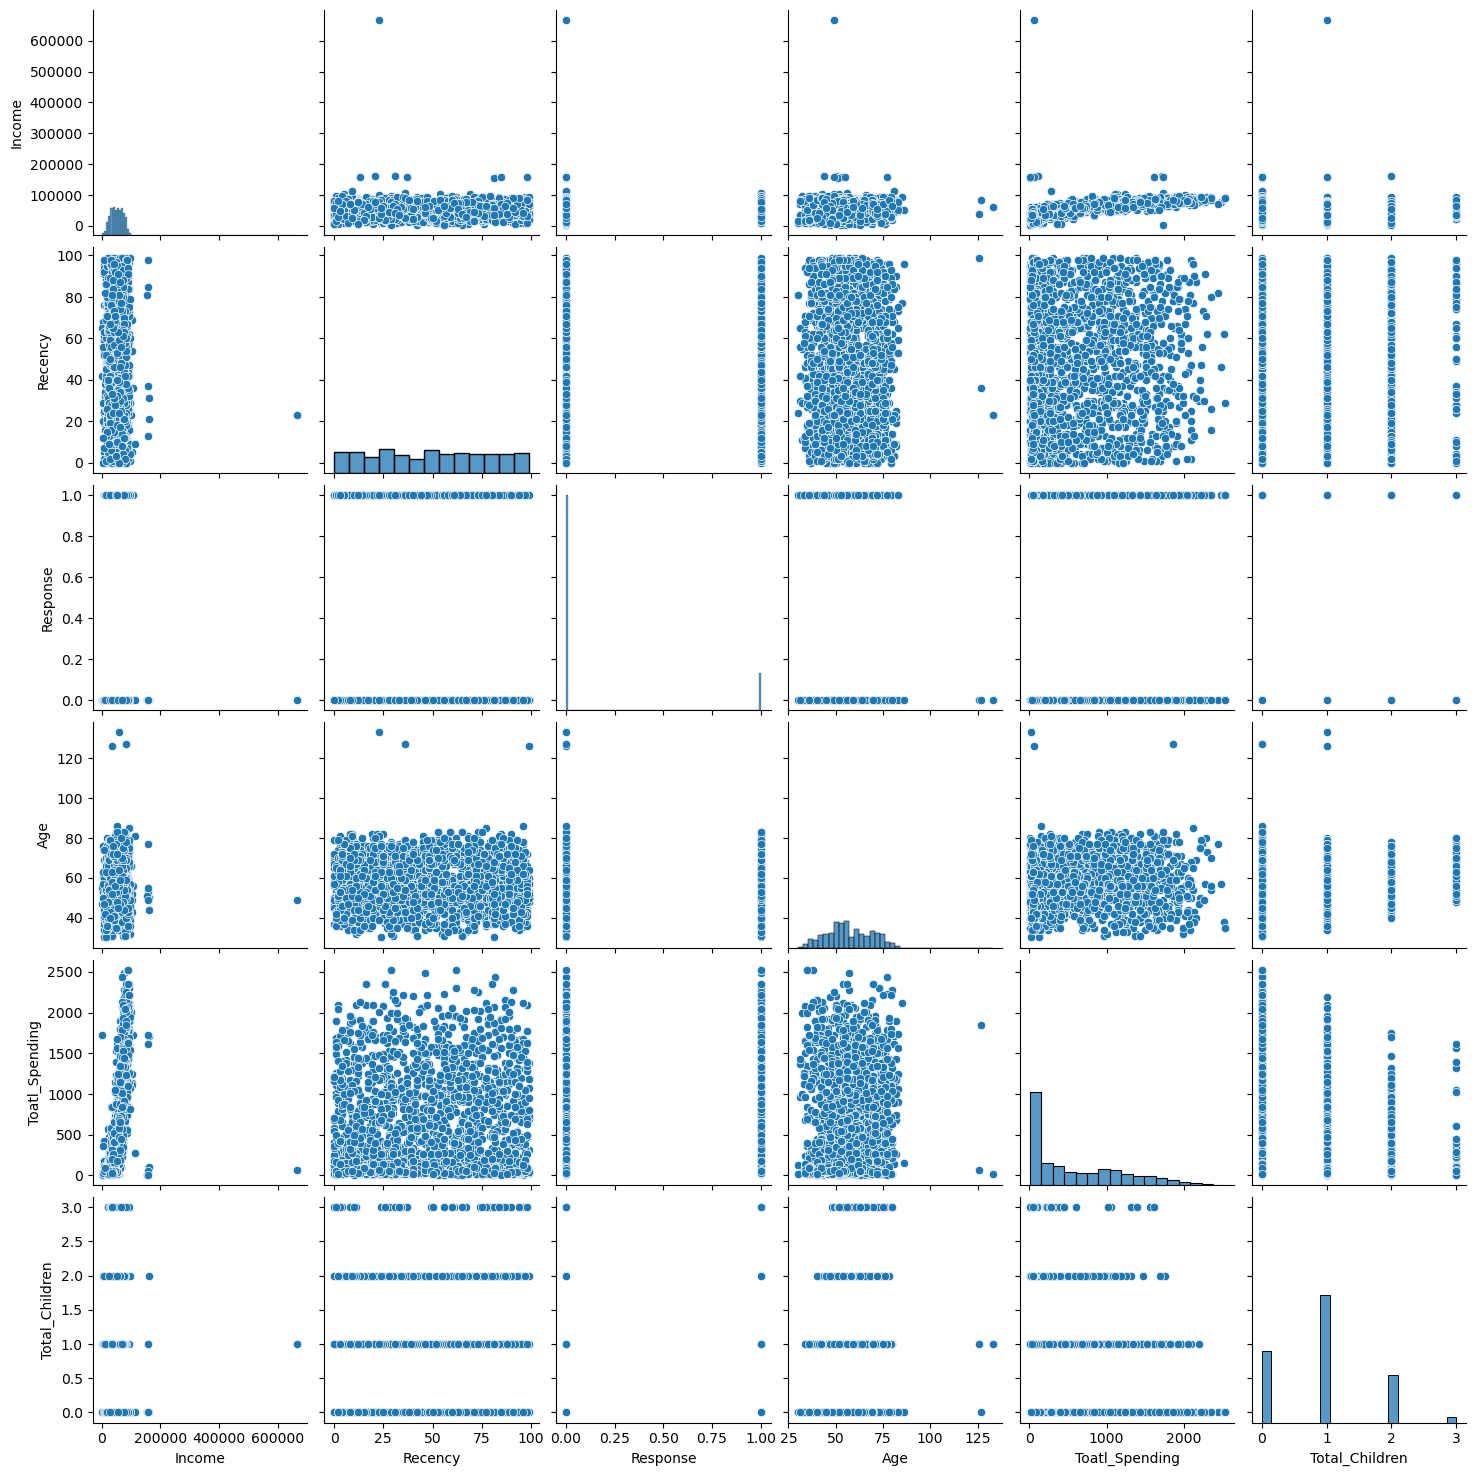

In [19]:
import seaborn as sns
cols=["Income","Recency","Response","Age","Toatl_Spending","Total_Children"]
sns.pairplot(cus_Cleaned[cols])

In [20]:
print("data with outlers:",len(cus_Cleaned))

cus_Cleaned=cus_Cleaned[(cus_Cleaned["Age"]<90)]
cus_Cleaned=cus_Cleaned[(cus_Cleaned["Income"]<6_00_000)]

print("Data After Outlers:",len(cus_Cleaned))

data with outlers: 2240
Data After Outlers: 2236


<Axes: >

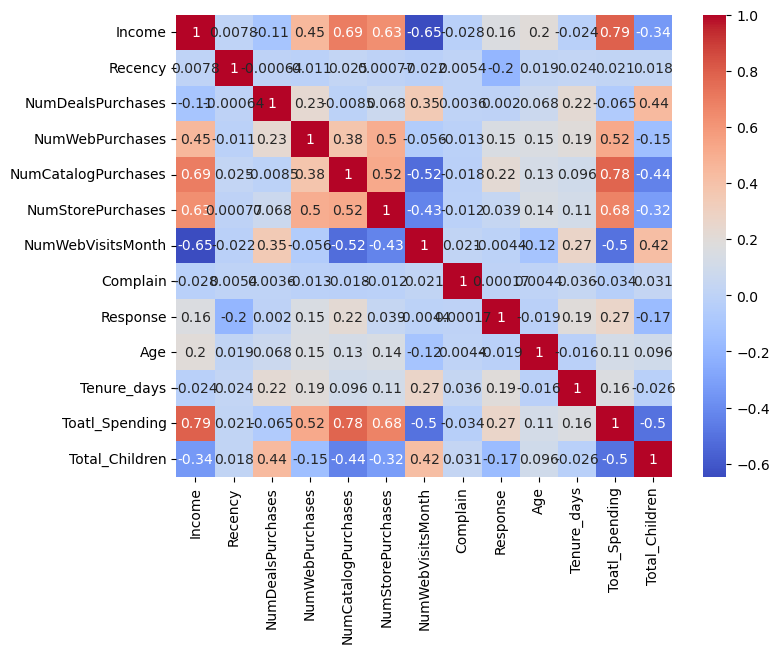

In [21]:
import matplotlib.pyplot as plt
corr=cus_Cleaned.corr(numeric_only=True) #This line calculates the correlation matrix between the numeric columns in the dataset.

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

Encoding

In [22]:
from sklearn.preprocessing import OneHotEncoder

In [23]:
ohe=OneHotEncoder()

cat_cols=["Education","Living_With"]

enc_cols=ohe.fit_transform(cus_Cleaned[cat_cols])

enc_cf=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=cus_Cleaned.index)


In [24]:
cus_encoded=pd.concat([cus_Cleaned.drop(columns=cat_cols),enc_cf],axis=1)


Scaling

In [25]:
cus_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Tenure_days,Toatl_Spending,Total_Children,Education_Graduation,Education_Postgraduate,Education_undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
X = cus_encoded

In [28]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [29]:
# 2D 
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

Text(0.5, 0, '3d projection')

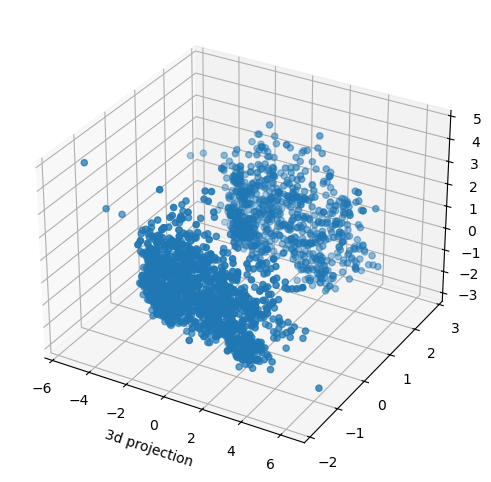

In [30]:
fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_xlabel("PCA2")
ax.set_xlabel("PCA3")
ax.set_xlabel("3d projection")



In [31]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)
    

In [32]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [33]:
print("best k =", optimal_k)

best k = 4


Text(0, 0.5, 'WCSS')

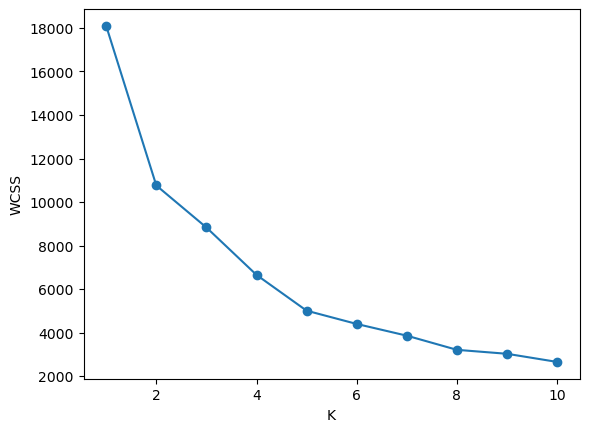

In [34]:
# plot

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

Text(0, 0.5, 'Silhouette score')

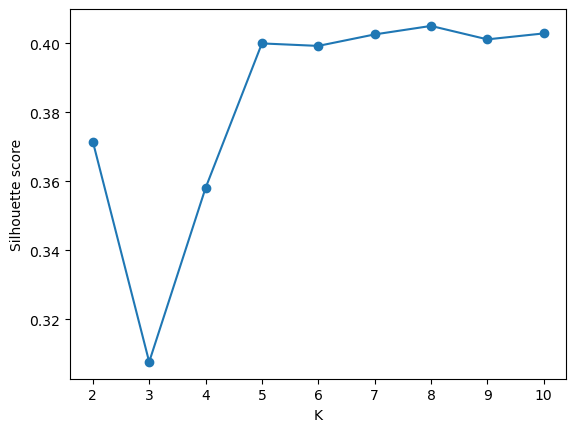

In [35]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# plot
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'SS')

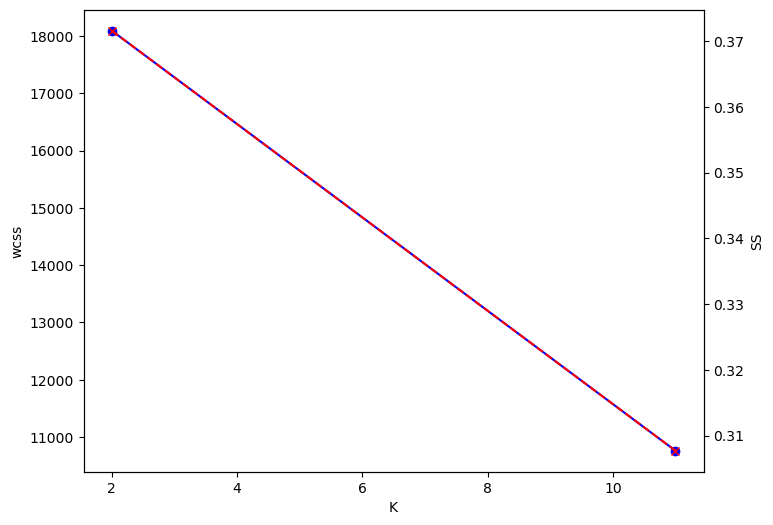

In [36]:
K_range=(2,11)

fig,ax1=plt.subplots(figsize=(8,6))

ax1.plot(K_range,wcss[:len(K_range)],marker="o",color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("wcss")

ax2=ax1.twinx()
ax2.plot(K_range,scores[:len(K_range)],marker="x",color="red",linestyle="--")
ax2.set_ylabel("SS")

In [37]:
# K_means

kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

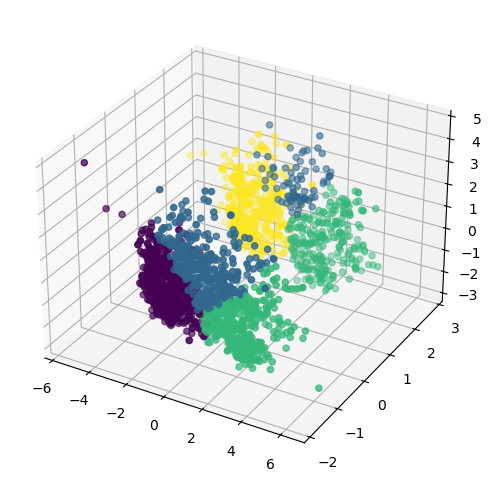

In [38]:

fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

In [39]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

In [40]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

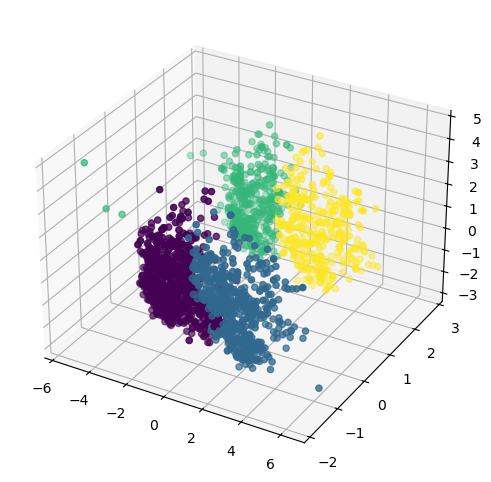

In [41]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

In [42]:

X["cluster"] = labels_agg

<Axes: xlabel='cluster', ylabel='count'>

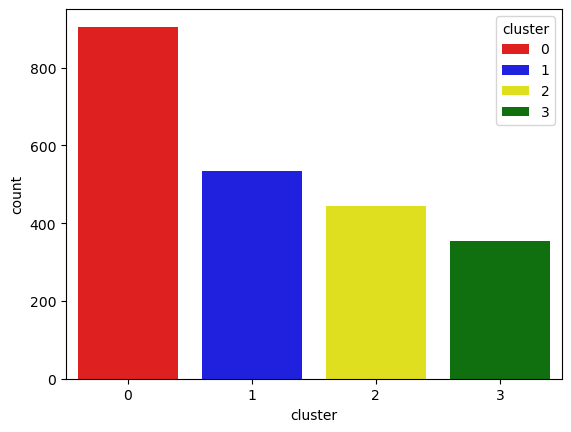

In [43]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Toatl_Spending', ylabel='Income'>

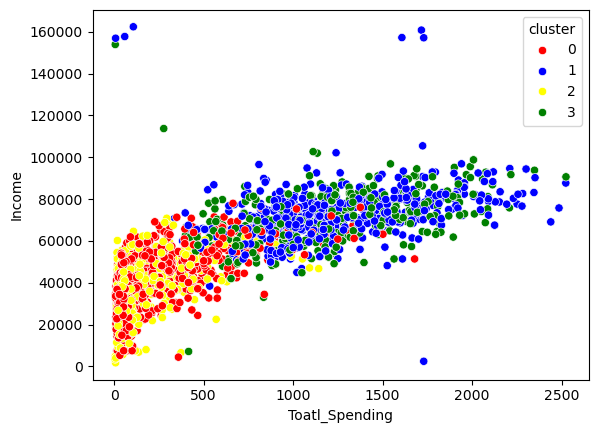

In [44]:
# Income & Spending patterns

sns.scatterplot(x=X["Toatl_Spending"], y=X["Income"], hue=X["cluster"], palette=pal)

In [45]:
# Cluster Summary

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Tenure_days  Toatl_Spending  Total_Children  \
cluster  